# 🎲 Clase 4 — Probabilidad y estadística
## Fundamentos del método científico y probabilidad

**Desafío inicial:** Un equipo de analítica en un e-commerce quiere predecir el comportamiento de compra durante el CyberDay. Los patrones se repiten, pero hay mucha variabilidad entre clientes. ¿Cómo representar formalmente eventos inciertos como clics, compras o rebotes?

**Objetivos:**
- Entender la relación entre **probabilidad** y **estadística**
- Distinguir **experimentos aleatorios** vs **determinísticos**
- Definir y trabajar con **espacio muestral** (S)
- Representar, clasificar y combinar **eventos aleatorios** (∪, ∩, complemento)
- Aplicar estos conceptos en Python con datos de e-commerce

In [1]:
%pip install matplotlib-venn 

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45437 sha256=b321c53bc409bcf3f3c59e424eb585bee66dd84ecba14c08beaef70201dc06f0
  Stored in directory: c:\users\natalie\appdata\local\pip\cache\wheels\c2\47\0c\f014c55a1cfd56dce41a1cafd23e3c590652b5e71330cc181c
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_venn as venn_lib   # pip install matplotlib-venn si es necesario
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Probabilidad vs Estadística

### 1.1 Diferencias fundamentales — slide 8

In [3]:
# Tabla slide 8
tabla_diff = pd.DataFrame({
    'Perspectiva': ['Probabilidad teórica','Estadística inferencial'],
    'Pregunta clave': [
        '¿Qué tan probable es que ocurra un evento dado un modelo?',
        '¿Qué modelo explica mejor los datos observados?'
    ],
    'Ejemplo en ciencia de datos': [
        'Si un modelo predice compras con 80% de confianza',
        'Analizar historiales para construir un modelo de compra'
    ],
    'Dirección': [
        'Modelo → Datos (del modelo a los datos)',
        'Datos → Modelo (de los datos al modelo)'
    ]
})
print('=== Probabilidad vs Estadística (slide 8) ===')
print(tabla_diff.to_string(index=False))

=== Probabilidad vs Estadística (slide 8) ===
            Perspectiva                                            Pregunta clave                             Ejemplo en ciencia de datos                               Dirección
   Probabilidad teórica ¿Qué tan probable es que ocurra un evento dado un modelo?       Si un modelo predice compras con 80% de confianza Modelo → Datos (del modelo a los datos)
Estadística inferencial           ¿Qué modelo explica mejor los datos observados? Analizar historiales para construir un modelo de compra Datos → Modelo (de los datos al modelo)


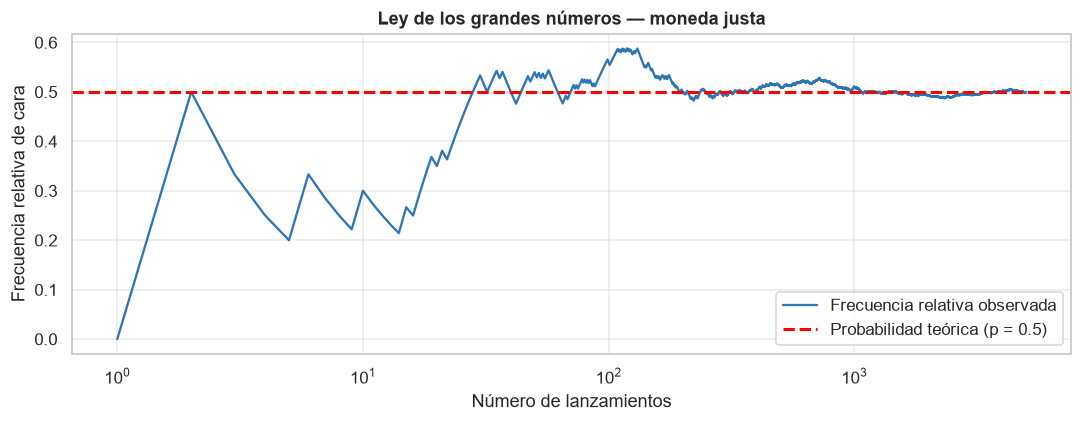

A medida que aumentan los lanzamientos, la frecuencia se acerca a la probabilidad teórica.
→ Esto conecta probabilidad (modelo) con estadística (datos observados).


In [4]:
# Demostración: la ley de los grandes números (probabilidad vs frecuencia)
np.random.seed(42)
n_max = 5000
lanzamientos = np.random.choice([0, 1], size=n_max)  # 0=cruz, 1=cara

frecuencias = np.cumsum(lanzamientos) / np.arange(1, n_max+1)

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_max+1), frecuencias, color='#2E75B6', linewidth=1.5,
         label='Frecuencia relativa observada')
plt.axhline(0.5, color='red', linestyle='--', linewidth=2,
            label='Probabilidad teórica (p = 0.5)')
plt.title('Ley de los grandes números — moneda justa', fontweight='bold')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Frecuencia relativa de cara')
plt.legend()
plt.xscale('log')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print('A medida que aumentan los lanzamientos, la frecuencia se acerca a la probabilidad teórica.')
print('→ Esto conecta probabilidad (modelo) con estadística (datos observados).')

---
## PARTE 2 — Experimentos aleatorios y determinísticos

### 2.1 Tabla comparativa — slides 12-15

In [5]:
tabla_exp = pd.DataFrame({
    'Característica': [
        'Resultado',
        'Predecible',
        'Variabilidad',
        'Herramienta',
        'Ejemplo cotidiano',
        'Ejemplo en ciencia de datos'
    ],
    'Determinístico': [
        'Único y fijo para cada entrada',
        '✅ Sí',
        '❌ No',
        'Lógica, álgebra, reglas fijas',
        'Encender una lámpara (interruptor OK)',
        'ETL con reglas fijas, f(x) = x + 1'
    ],
    'Aleatorio': [
        'Variable entre repeticiones',
        '❌ No',
        '✅ Sí (inherente)',
        'Probabilidad, distribuciones',
        'Lanzar un dado',
        'Tasa de clics en publicidad, churn'
    ]
})
print('=== Experimento determinístico vs aleatorio (slides 12-15) ===')
print(tabla_exp.to_string(index=False))

=== Experimento determinístico vs aleatorio (slides 12-15) ===
             Característica                        Determinístico                          Aleatorio
                  Resultado        Único y fijo para cada entrada        Variable entre repeticiones
                 Predecible                                  ✅ Sí                               ❌ No
               Variabilidad                                  ❌ No                   ✅ Sí (inherente)
                Herramienta         Lógica, álgebra, reglas fijas       Probabilidad, distribuciones
          Ejemplo cotidiano Encender una lámpara (interruptor OK)                     Lanzar un dado
Ejemplo en ciencia de datos    ETL con reglas fijas, f(x) = x + 1 Tasa de clics en publicidad, churn


In [6]:
# Demostración en código: determinístico vs aleatorio
print('=== Experimento DETERMINÍSTICO: f(x) = x + 1 ===')
for x in [3, 3, 3]:   # siempre mismo resultado
    print(f'  f({x}) = {x + 1}')
print('Mismo input → mismo output siempre ✅')
print()

print('=== Experimento ALEATORIO: lanzar un dado ===')
np.random.seed(None)  # sin semilla fija
for i in range(5):
    resultado = np.random.randint(1, 7)
    print(f'  Lanzamiento {i+1}: {resultado}')
print('Mismo proceso → resultados distintos (variabilidad intrínseca) ✅')
print()

# Aplicaciones en ciencia de datos — slide 15
tabla_app = pd.DataFrame({
    'Área': ['Comportamiento humano','Sistemas en red','Marketing'],
    'Experimento aleatorio': [
        'Predicción de churn, patrones de navegación web',
        'Tiempos de respuesta de servidores, disponibilidad',
        'Desempeño de campañas, tasas de conversión'
    ]
})
print('=== Aplicaciones del experimento aleatorio (slide 15) ===')
print(tabla_app.to_string(index=False))

=== Experimento DETERMINÍSTICO: f(x) = x + 1 ===
  f(3) = 4
  f(3) = 4
  f(3) = 4
Mismo input → mismo output siempre ✅

=== Experimento ALEATORIO: lanzar un dado ===
  Lanzamiento 1: 2
  Lanzamiento 2: 2
  Lanzamiento 3: 4
  Lanzamiento 4: 2
  Lanzamiento 5: 3
Mismo proceso → resultados distintos (variabilidad intrínseca) ✅

=== Aplicaciones del experimento aleatorio (slide 15) ===
                 Área                              Experimento aleatorio
Comportamiento humano    Predicción de churn, patrones de navegación web
      Sistemas en red Tiempos de respuesta de servidores, disponibilidad
            Marketing         Desempeño de campañas, tasas de conversión


### ✏️ Ejercicio 2:

In [7]:
# ✏️ Clasifica cada proceso como DETERMINÍSTICO (D) o ALEATORIO (A):
clasificaciones = {
    'Un pipeline ETL que limpia valores nulos con la misma regla':    '',
    'El comportamiento de clic de un usuario en un banner':           '',
    'Calcular el promedio de una lista numérica':                     '',
    'La cantidad de llamadas que recibirá un call center mañana':     '',
    'El resultado de ordenar un DataFrame por fecha':                 '',
    'El tiempo que tarda un servidor en responder bajo carga':        '',
}

print('--- CLASIFICACIÓN D/A ---')
for proc, tipo in clasificaciones.items():
    print(f'[{tipo}] {proc}')

# ✏️ Pregunta de cierre 1:
c1 = ""
print(f'\n¿Diferencia aleatorio vs determinístico?: {c1}')

--- CLASIFICACIÓN D/A ---
[] Un pipeline ETL que limpia valores nulos con la misma regla
[] El comportamiento de clic de un usuario en un banner
[] Calcular el promedio de una lista numérica
[] La cantidad de llamadas que recibirá un call center mañana
[] El resultado de ordenar un DataFrame por fecha
[] El tiempo que tarda un servidor en responder bajo carga

¿Diferencia aleatorio vs determinístico?: 


---
## PARTE 3 — Espacio muestral

### 3.1 Definición y tipos — slides 19-20

In [8]:
# Ejemplos del slide 19
S_dado    = {1, 2, 3, 4, 5, 6}
S_clic    = {'clic', 'no_clic'}
S_web     = {'abandono', 'interaccion_sin_compra', 'compra'}  # slide 22

print('=== Espacios muestrales (slide 19) ===')
print(f'Dado:       S = {S_dado}  | |S| = {len(S_dado)}')
print(f'Test mktg:  S = {S_clic}  | |S| = {len(S_clic)}')
print(f'Web (slide 22): S = {S_web}')
print()

# Tabla de tipos — slide 20
tabla_tipos_s = pd.DataFrame({
    'Tipo': ['Finito','Infinito numerable','Infinito no numerable'],
    'Descripción': [
        'Número limitado de resultados',
        'Infinitos resultados, pero se pueden contar',
        'Infinitos resultados no contables'
    ],
    'Ejemplo en datos': [
        'Lanzar un dado (6 posibles resultados)',
        'Número de intentos hasta lograr una venta',
        'Tiempo exacto (segundos) hasta cerrar una venta'
    ],
    'En Python': [
        'set con valores discretos',
        'range(1, inf) — contador',
        'np.random.uniform() — continuo'
    ]
})
print('=== Tipos de espacio muestral (slide 20) ===')
print(tabla_tipos_s.to_string(index=False))

=== Espacios muestrales (slide 19) ===
Dado:       S = {1, 2, 3, 4, 5, 6}  | |S| = 6
Test mktg:  S = {'clic', 'no_clic'}  | |S| = 2
Web (slide 22): S = {'abandono', 'compra', 'interaccion_sin_compra'}

=== Tipos de espacio muestral (slide 20) ===
                 Tipo                                 Descripción                                Ejemplo en datos                      En Python
               Finito               Número limitado de resultados          Lanzar un dado (6 posibles resultados)      set con valores discretos
   Infinito numerable Infinitos resultados, pero se pueden contar       Número de intentos hasta lograr una venta       range(1, inf) — contador
Infinito no numerable           Infinitos resultados no contables Tiempo exacto (segundos) hasta cerrar una venta np.random.uniform() — continuo


In [9]:
# Construir el espacio muestral con datos reales — código exacto slide 36
import pandas as pd

df = pd.read_csv('interacciones_clientes.csv')
print(df.head())
print()

# Código exacto del slide 36
espacio_muestral = df['tipo_interaccion'].unique()
print('=== Espacio muestral (slide 36) ===')
print(espacio_muestral)

  usuario_id   tipo_interaccion  tiempo_sitio dispositivo      fuente  \
0      U0001      compra_simple           346       móvil    orgánico   
1      U0002  visita_sin_compra            50       móvil        RRSS   
2      U0003      compra_simple           278       móvil       email   
3      U0004   abandono_carrito           171     desktop  publicidad   
4      U0005   abandono_carrito           237       móvil        RRSS   

   valor_compra  
0        112256  
1         39425  
2         66749  
3             0  
4             0  

=== Espacio muestral (slide 36) ===
<StringArray>
[    'compra_simple', 'visita_sin_compra',  'abandono_carrito',
    'compra_reclamo', 'compra_devolucion']
Length: 5, dtype: str


In [10]:
# Frecuencias de cada evento — código exacto slide 36
eventos = df['tipo_interaccion'].value_counts(normalize=True)
print('=== Probabilidades empíricas por evento (slide 36) ===')
print(eventos.round(4))
print()
print(f'Suma total: {eventos.sum():.4f}  ← debe ser 1.0 ✅')

=== Probabilidades empíricas por evento (slide 36) ===
tipo_interaccion
visita_sin_compra    0.370
compra_simple        0.280
abandono_carrito     0.186
compra_reclamo       0.122
compra_devolucion    0.042
Name: proportion, dtype: float64

Suma total: 1.0000  ← debe ser 1.0 ✅


---
## PARTE 4 — Eventos aleatorios y operaciones

### 4.1 Definición formal y clasificación — slides 26-29

In [11]:
# Ejemplo exacto del slide 26
S_dado_set = {1, 2, 3, 4, 5, 6}
A = {2, 4, 6}        # números pares
B = {5, 6}           # números > 4

print('=== Eventos sobre S = {1,2,3,4,5,6} (slide 26) ===')
print(f'A (números pares):    A = {A}')
print(f'B (números > 4):      B = {B}')
print()

# Operaciones con eventos — slide 27
union_AB   = A | B           # A ∪ B
inter_AB   = A & B           # A ∩ B
comp_A     = S_dado_set - A  # ¬A
dif_A_B    = A - B           # A − B

print('=== Operaciones con eventos (slide 27) ===')
print(f'A ∪ B  (Unión):        {sorted(union_AB)}  → A o B o ambos')
print(f'A ∩ B  (Intersección): {sorted(inter_AB)}  → A y B simultáneos')
print(f'¬A     (Complemento):  {sorted(comp_A)}  → NO ocurre A')
print(f'A − B  (Diferencia):   {sorted(dif_A_B)}  → A pero NO B')

print()
# Tabla clasificación — slide 29
tabla_clas = pd.DataFrame({
    'Tipo': ['Elemental','Compuesto','Seguro','Imposible'],
    'Descripción': [
        'Contiene un solo resultado',
        'Contiene múltiples resultados',
        'Siempre ocurre',
        'Nunca ocurre'
    ],
    'Ejemplo dado': ['A = {3}','A = {2,4,6}','S = {1,2,3,4,5,6}','∅ = {}']
})
print('=== Clasificación de eventos (slide 29) ===')
print(tabla_clas.to_string(index=False))

=== Eventos sobre S = {1,2,3,4,5,6} (slide 26) ===
A (números pares):    A = {2, 4, 6}
B (números > 4):      B = {5, 6}

=== Operaciones con eventos (slide 27) ===
A ∪ B  (Unión):        [2, 4, 5, 6]  → A o B o ambos
A ∩ B  (Intersección): [6]  → A y B simultáneos
¬A     (Complemento):  [1, 3, 5]  → NO ocurre A
A − B  (Diferencia):   [2, 4]  → A pero NO B

=== Clasificación de eventos (slide 29) ===
     Tipo                   Descripción      Ejemplo dado
Elemental    Contiene un solo resultado           A = {3}
Compuesto Contiene múltiples resultados       A = {2,4,6}
   Seguro                Siempre ocurre S = {1,2,3,4,5,6}
Imposible                  Nunca ocurre            ∅ = {}


C:\Users\Natalie\AppData\Local\Temp\ipykernel_25984\557200869.py:15: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Natalie\anaconda3\envs\BootcampCienciaDeDatos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


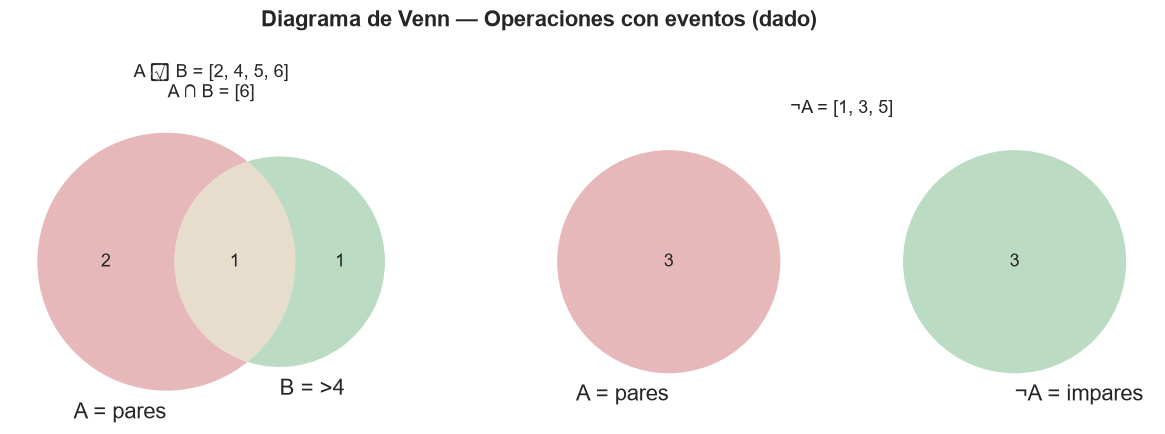

In [12]:
# Diagrama de Venn para visualizar operaciones (slide 32 buenas prácticas)
try:
    from matplotlib_venn import venn2
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Diagrama de Venn — Operaciones con eventos (dado)', fontweight='bold')

    # Venn A y B
    v = venn2([A, B], set_labels=('A = pares', 'B = >4'), ax=axes[0])
    axes[0].set_title(f'A ∪ B = {sorted(union_AB)}\nA ∩ B = {sorted(inter_AB)}')

    # Complemento de A
    venn2([A, comp_A], set_labels=('A = pares', '¬A = impares'), ax=axes[1])
    axes[1].set_title(f'¬A = {sorted(comp_A)}')

    plt.tight_layout()
    plt.show()
except ImportError:
    # Si no está instalado matplotlib-venn, usar visualización alternativa
    print('matplotlib-venn no disponible. Mostrando representación alternativa:')
    fig, ax = plt.subplots(figsize=(8, 4))

    sets_info = [
        ('A (pares)',    sorted(A),         '#2E75B6', 0.3),
        ('B (> 4)',      sorted(B),         '#ED7D31', 0.7),
        ('A ∪ B',       sorted(union_AB),  '#70AD47', 0.0),
        ('A ∩ B',       sorted(inter_AB),  '#7030A0', 1.0),
        ('¬A',          sorted(comp_A),    '#A5A5A5', 0.0),
    ]
    for i, (nombre, elementos, color, _) in enumerate(sets_info):
        ax.barh(i, 1, color=color, alpha=0.6, edgecolor='white')
        ax.text(0.02, i, f'{nombre}: {elementos}', va='center', fontsize=9)

    ax.set_xlim(0, 1.5)
    ax.set_yticks(range(len(sets_info)))
    ax.set_yticklabels([s[0] for s in sets_info])
    ax.set_title('Operaciones con eventos — Dado')
    plt.tight_layout()
    plt.show()

---
## PARTE 5 — Actividad guiada: E-commerce (slides 33-38)

### 5.1 Cargar datos — código exacto slide 36

In [13]:
# Código exacto del slide 36
import pandas as pd

df = pd.read_csv('interacciones_clientes.csv')
print(df.head())

  usuario_id   tipo_interaccion  tiempo_sitio dispositivo      fuente  \
0      U0001      compra_simple           346       móvil    orgánico   
1      U0002  visita_sin_compra            50       móvil        RRSS   
2      U0003      compra_simple           278       móvil       email   
3      U0004   abandono_carrito           171     desktop  publicidad   
4      U0005   abandono_carrito           237       móvil        RRSS   

   valor_compra  
0        112256  
1         39425  
2         66749  
3             0  
4             0  


### 5.2 Paso 1 — Identificar el experimento aleatorio

In [14]:
# ✏️ Paso 1 — Instrucciones slide 36
# Identificar el experimento aleatorio y su espacio muestral

print('=== PASO 1: Experimento aleatorio ===')
print('Experimento: observar el tipo de interacción de un usuario al visitar el sitio')
print()

espacio_muestral = df['tipo_interaccion'].unique()
print('=== Espacio muestral S (slide 36) ===')
print(f'S = {set(espacio_muestral)}')
print(f'|S| = {len(espacio_muestral)} resultados posibles')
print()

print('Tipo de espacio muestral: FINITO (número limitado de categorías)')

# ✏️ Completar:
exp_aleatorio_descripcion = ""
print(f'Descripción del experimento: {exp_aleatorio_descripcion}')

=== PASO 1: Experimento aleatorio ===
Experimento: observar el tipo de interacción de un usuario al visitar el sitio

=== Espacio muestral S (slide 36) ===
S = {'compra_devolucion', 'visita_sin_compra', 'compra_reclamo', 'compra_simple', 'abandono_carrito'}
|S| = 5 resultados posibles

Tipo de espacio muestral: FINITO (número limitado de categorías)
Descripción del experimento: 


### 5.3 Paso 2 — Contar frecuencias y calcular probabilidades

tipo_interaccion
visita_sin_compra    0.370
compra_simple        0.280
abandono_carrito     0.186
compra_reclamo       0.122
compra_devolucion    0.042
Name: proportion, dtype: float64



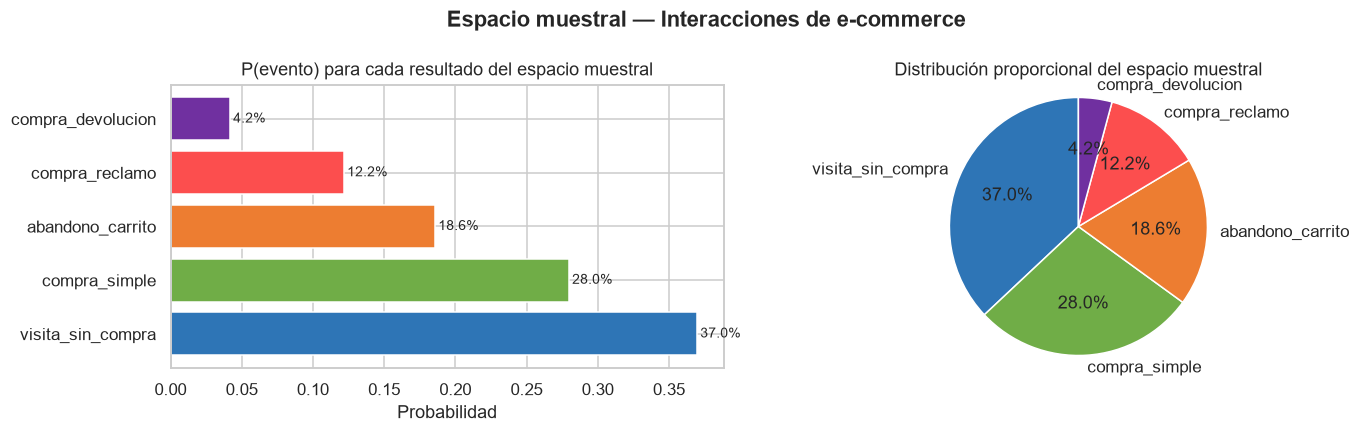

In [15]:
# Código exacto del slide 36
eventos = df['tipo_interaccion'].value_counts(normalize=True)
print(eventos)
print()

# Visualización de las probabilidades
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Espacio muestral — Interacciones de e-commerce', fontweight='bold')

# Barras de probabilidad
colores = ['#2E75B6','#70AD47','#ED7D31','#FC4E4E','#7030A0']
df_ev = eventos.reset_index()
df_ev.columns = ['tipo','prob']
axes[0].barh(df_ev['tipo'], df_ev['prob'], color=colores[:len(df_ev)], edgecolor='white')
axes[0].set_title('P(evento) para cada resultado del espacio muestral')
axes[0].set_xlabel('Probabilidad')
for i, (_, row) in enumerate(df_ev.iterrows()):
    axes[0].text(row['prob']+0.002, i, f'{row["prob"]*100:.1f}%', va='center', fontsize=9)

# Torta
axes[1].pie(df_ev['prob'], labels=df_ev['tipo'], autopct='%1.1f%%',
            startangle=90, colors=colores[:len(df_ev)])
axes[1].set_title('Distribución proporcional del espacio muestral')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

### 5.4 Paso 3 — Definir eventos compuestos y calcular probabilidades

In [16]:
# Código exacto del slide 37
evento_compra = df['tipo_interaccion'].isin(['compra_simple', 'compra_reclamo'])
prob_evento = evento_compra.mean()
print(f'Probabilidad de compra: {prob_evento:.2f}')

condicion = df['tipo_interaccion'] == 'compra_reclamo'
print(f'Probabilidad de compra con reclamo: {condicion.mean():.2f}')

Probabilidad de compra: 0.40
Probabilidad de compra con reclamo: 0.12


In [17]:
# Eventos compuestos definidos — instrucciones slide 37

# Evento A: cualquier tipo de compra (compra_simple, compra_reclamo, compra_devolucion)
A_compra = df['tipo_interaccion'].isin(['compra_simple','compra_reclamo','compra_devolucion'])

# Evento B: interacción sin conversión (visita_sin_compra, abandono_carrito)
B_sin_conv = df['tipo_interaccion'].isin(['visita_sin_compra','abandono_carrito'])

# Evento C: compra problemática (reclamo o devolución)
C_problema = df['tipo_interaccion'].isin(['compra_reclamo','compra_devolucion'])

# Complemento de A: no compró
not_A = ~A_compra

print('=== Eventos compuestos e-commerce ===')
print(f'P(A) = Compra (cualquier tipo):         {A_compra.mean():.4f}  ({A_compra.sum()} usuarios)')
print(f'P(B) = Sin conversión:                  {B_sin_conv.mean():.4f}  ({B_sin_conv.sum()} usuarios)')
print(f'P(C) = Compra problemática:             {C_problema.mean():.4f}  ({C_problema.sum()} usuarios)')
print(f'P(¬A) = No compró (complemento):        {not_A.mean():.4f}  ({not_A.sum()} usuarios)')
print()
print(f'Verificación: P(A) + P(¬A) = {A_compra.mean() + not_A.mean():.4f}  ← debe ser 1.0 ✅')

=== Eventos compuestos e-commerce ===
P(A) = Compra (cualquier tipo):         0.4440  (222 usuarios)
P(B) = Sin conversión:                  0.5560  (278 usuarios)
P(C) = Compra problemática:             0.1640  (82 usuarios)
P(¬A) = No compró (complemento):        0.5560  (278 usuarios)

Verificación: P(A) + P(¬A) = 1.0000  ← debe ser 1.0 ✅


In [18]:
# Paso 4 — Intersección de eventos — instrucciones slide 37
# ¿Qué probabilidad hay de que alguien compre y luego reclame?

# Intersección A ∩ C: compra Y problemática
inter_A_C = A_compra & C_problema

# Unión A ∪ B: compra O sin conversión
union_A_B = A_compra | B_sin_conv

# Diferencia A − C: compró pero NO tuvo problema
dif_A_C = A_compra & ~C_problema

print('=== Operaciones con eventos (slide 37) ===')
print(f'P(A ∩ C) = compra Y problemática:        {inter_A_C.mean():.4f}  → {inter_A_C.sum()} usuarios')
print(f'P(A ∪ B) = compra O sin conversión:      {union_A_B.mean():.4f}  → {union_A_B.sum()} usuarios')
print(f'P(A − C) = compró sin problema:          {dif_A_C.mean():.4f}  → {dif_A_C.sum()} usuarios')
print()

# Respuesta a la pregunta del slide 37
prob_compra_reclamo = (df['tipo_interaccion'] == 'compra_reclamo').mean()
print(f'\n¿Probabilidad de comprar y reclamar?: {prob_compra_reclamo:.4f}')
print(f'Dado que compró, ¿P(reclamo | compra)? = {inter_A_C.mean() / A_compra.mean():.4f}')

=== Operaciones con eventos (slide 37) ===
P(A ∩ C) = compra Y problemática:        0.1640  → 82 usuarios
P(A ∪ B) = compra O sin conversión:      1.0000  → 500 usuarios
P(A − C) = compró sin problema:          0.2800  → 140 usuarios


¿Probabilidad de comprar y reclamar?: 0.1220
Dado que compró, ¿P(reclamo | compra)? = 0.3694


### 5.5 Plantilla de documentación — slide 38

In [19]:
# Plantilla editable — documentar espacio muestral y eventos
n_total = len(df)

plantilla = pd.DataFrame({
    'Evento': [
        'A — Compra (cualquier tipo)',
        'B — Sin conversión',
        'C — Compra problemática',
        '¬A — No compró',
        'A ∩ C — Compra y problemática',
        'A ∪ B — Compra o sin conversión',
        'A − C — Compró sin problema'
    ],
    'Elementos del espacio muestral': [
        'compra_simple, compra_reclamo, compra_devolucion',
        'visita_sin_compra, abandono_carrito',
        'compra_reclamo, compra_devolucion',
        'visita_sin_compra, abandono_carrito',
        'compra_reclamo, compra_devolucion',
        'todos excepto visita_sin_compra, abandono_carrito duplicado',
        'solo compra_simple'
    ],
    'N observaciones': [
        A_compra.sum(), B_sin_conv.sum(), C_problema.sum(),
        not_A.sum(), inter_A_C.sum(), union_A_B.sum(), dif_A_C.sum()
    ],
    'Probabilidad': [
        round(A_compra.mean(),4), round(B_sin_conv.mean(),4), round(C_problema.mean(),4),
        round(not_A.mean(),4), round(inter_A_C.mean(),4), round(union_A_B.mean(),4),
        round(dif_A_C.mean(),4)
    ],
    'Tipo': [
        'Compuesto','Compuesto','Compuesto',
        'Complemento','Intersección','Unión','Diferencia'
    ]
})

print(f'N total = {n_total} usuarios')
print()
print('=== PLANTILLA DOCUMENTADA — Espacio muestral y eventos (slide 38) ===')
print(plantilla.to_string(index=False))

N total = 500 usuarios

=== PLANTILLA DOCUMENTADA — Espacio muestral y eventos (slide 38) ===
                         Evento                              Elementos del espacio muestral  N observaciones  Probabilidad         Tipo
    A — Compra (cualquier tipo)            compra_simple, compra_reclamo, compra_devolucion              222         0.444    Compuesto
             B — Sin conversión                         visita_sin_compra, abandono_carrito              278         0.556    Compuesto
        C — Compra problemática                           compra_reclamo, compra_devolucion               82         0.164    Compuesto
                 ¬A — No compró                         visita_sin_compra, abandono_carrito              278         0.556  Complemento
  A ∩ C — Compra y problemática                           compra_reclamo, compra_devolucion               82         0.164 Intersección
A ∪ B — Compra o sin conversión todos excepto visita_sin_compra, abandono_carrito duplicad

=== Desglose por dispositivo ===
dispositivo
desktop    0.4634
móvil      0.4221
tablet     0.5106
Name: compro, dtype: float64


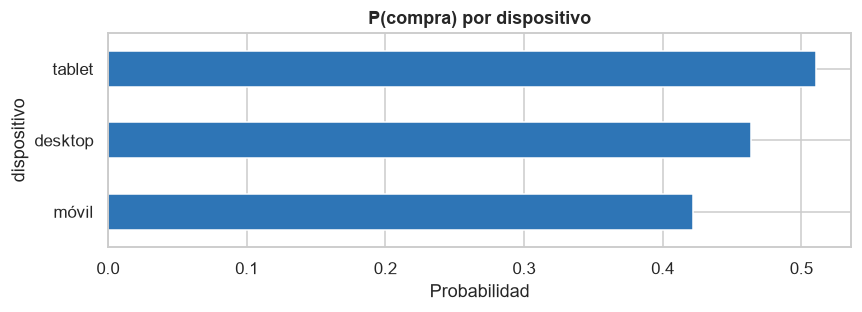

In [20]:
# Análisis adicional por dispositivo
print('=== Desglose por dispositivo ===')
prob_compra_disp = df.assign(
    compro=A_compra
).groupby('dispositivo')['compro'].mean().round(4)
print(prob_compra_disp)

plt.figure(figsize=(8, 3))
prob_compra_disp.sort_values().plot(kind='barh', color='#2E75B6', edgecolor='white')
plt.title('P(compra) por dispositivo', fontweight='bold')
plt.xlabel('Probabilidad')
plt.tight_layout()
plt.show()

### ✏️ Preguntas de cierre — slide 41:

In [21]:
p1 = ""  # ¿Diferencia aleatorio vs determinístico?
p2 = ""  # ¿Cómo definirías el espacio muestral en A/B testing?
p3 = ""  # ¿Qué tipo de evento es una combinación de condiciones?
p4 = ""  # ¿Utilidad de unión e intersección en modelos predictivos?
p5 = ""  # ¿Qué errores sin definir bien los eventos?

preguntas = [
    '¿Qué diferencia a un experimento aleatorio de uno determinístico y por qué importa en ciencia de datos?',
    '¿Cómo definirías el espacio muestral en un experimento de A/B testing?',
    '¿Qué tipo de evento representa una combinación de condiciones y cómo se expresa formalmente?',
    '¿Cuál es la utilidad de aplicar unión o intersección entre eventos en un modelo predictivo?',
    '¿Qué errores podrías cometer si no defines correctamente los eventos antes de modelar?'
]

print('--- PREGUNTAS DE CIERRE (slide 41) ---')
for i, (preg, resp) in enumerate(zip(preguntas, [p1,p2,p3,p4,p5]), 1):
    print(f'\n{i}. {preg}')
    print(f'   R: {resp}')

--- PREGUNTAS DE CIERRE (slide 41) ---

1. ¿Qué diferencia a un experimento aleatorio de uno determinístico y por qué importa en ciencia de datos?
   R: 

2. ¿Cómo definirías el espacio muestral en un experimento de A/B testing?
   R: 

3. ¿Qué tipo de evento representa una combinación de condiciones y cómo se expresa formalmente?
   R: 

4. ¿Cuál es la utilidad de aplicar unión o intersección entre eventos en un modelo predictivo?
   R: 

5. ¿Qué errores podrías cometer si no defines correctamente los eventos antes de modelar?
   R: 


---
## 📋 Resumen

### Probabilidad vs Estadística

| | Probabilidad | Estadística |
|-|-------------|-------------|
| Dirección | Modelo → Datos | Datos → Modelo |
| Pregunta | ¿Qué tan probable si conozco el sistema? | ¿Qué sistema subyace a los datos? |
| Ejemplo | Si p=0.80, ¿qué predicción hago? | ¿Qué p se ajusta a los datos observados? |

### Operaciones con eventos en Python (pandas)

| Operación | Símbolo | Pandas | Descripción |
|-----------|---------|--------|-------------|
| Unión | A ∪ B | `A \| B` | A o B o ambos |
| Intersección | A ∩ B | `A & B` | A y B simultáneos |
| Complemento | ¬A | `~A` | No A |
| Diferencia | A − B | `A & ~B` | A pero no B |
| Probabilidad | P(A) | `A.mean()` | Frecuencia relativa |

### Buenas prácticas (slides 10, 17, 23, 32)

| Práctica | Por qué importa |
|---------|----------------|
| Distinguir datos de probabilidades teóricas | Los datos describen el pasado; la probabilidad modela el futuro |
| Validar supuestos (independencia, aleatoriedad) | Un supuesto inválido invalida toda inferencia |
| Definir el espacio muestral antes de modelar | Error aquí = error en todo el modelo |
| Documentar eventos con notación formal y código | Trazabilidad y reproducibilidad |
| Verificar que P(S) = 1 | Sanidad básica del modelo |

> 💡 **Ley de los grandes números:** con suficientes repeticiones, la frecuencia relativa observada converge a la probabilidad teórica. Esto es la base que conecta estadística descriptiva con probabilidad.

> 💡 **Espacio muestral en pandas:** `df['col'].unique()` para construirlo, `df['col'].value_counts(normalize=True)` para estimar probabilidades empíricas.